# Avaliação Prática — Regressão Linear: Previsão do Valor de Imóveis

**Dataset:** House Price Regression Dataset — Kaggle  
**Objetivo:** criar um modelo simples de Regressão Linear para prever o preço de imóveis.

Nesta atividade, você deverá trabalhar com análise inicial dos dados, validação holdout, criação de modelo de Regressão Linear e avaliação usando MAE e MSE.

> Observação: nesta atividade não será necessário fazer pré-processamento avançado, normalização ou tratamento complexo dos dados.

## Parte 1 — Importação das bibliotecas

Importe as bibliotecas necessárias para trabalhar com dados, gráficos, separação holdout, Regressão Linear e métricas de avaliação.

In [1]:
# TODO: importe as bibliotecas necessárias

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# importe train_test_split
# importe LinearRegression
# importe mean_absolute_error e mean_squared_error

## Parte 2 — Carregamento do dataset

Carregue o arquivo `house_price_regression_dataset.csv` em um DataFrame chamado `df`. Depois, exiba as 5 primeiras linhas.

In [2]:
# TODO: carregue o dataset

arquivo = "house_price_regression_dataset.csv"

df = pd.read_csv(arquivo)
df.head()

# Exiba as 5 primeiras linhas
# df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## Parte 3 — Análise inicial dos dados

Responda às perguntas abaixo usando comandos do Pandas:

1. Quantas linhas e colunas existem no dataset?
2. Quais são as colunas disponíveis?
3. Existem valores nulos?
4. Quais são as principais estatísticas das colunas numéricas?

In [3]:
# TODO: veja o tamanho do dataset
# df.shape

print(f"Tamanho do dataset: {df.shape}")

Tamanho do dataset: (1000, 8)


In [4]:
# TODO: veja as colunas do dataset
# df.columns

print(f"Todas as colunas do dataset: {df.columns}")

Todas as colunas do dataset: Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')


In [5]:
# TODO: verifique valores nulos
# df.isnull().sum()

print(f"Contagem dos valores nulos:\n{df.isnull().sum()}")

Contagem dos valores nulos:
Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


In [6]:
# TODO: análise estatística simples
# df.describe()

print(df.describe())

       Square_Footage  Num_Bedrooms  Num_Bathrooms   Year_Built     Lot_Size  \
count     1000.000000   1000.000000    1000.000000  1000.000000  1000.000000   
mean      2815.422000      2.990000       1.973000  1986.550000     2.778087   
std       1255.514921      1.427564       0.820332    20.632916     1.297903   
min        503.000000      1.000000       1.000000  1950.000000     0.506058   
25%       1749.500000      2.000000       1.000000  1969.000000     1.665946   
50%       2862.500000      3.000000       2.000000  1986.000000     2.809740   
75%       3849.500000      4.000000       3.000000  2004.250000     3.923317   
max       4999.000000      5.000000       3.000000  2022.000000     4.989303   

       Garage_Size  Neighborhood_Quality   House_Price  
count  1000.000000           1000.000000  1.000000e+03  
mean      1.022000              5.615000  6.188610e+05  
std       0.814973              2.887059  2.535681e+05  
min       0.000000              1.000000  1.116269e

### Resposta da análise inicial

Escreva aqui uma breve conclusão sobre o dataset:

- O dataset possui quantas linhas?
R: O dataset possui 1000 linhas.

- O dataset possui quantas colunas?
R: O dataset possui 8 colunas.

- Existem valores nulos?
R: Não tem valor nulo.

- O que você percebeu sobre o preço dos imóveis?
R: A casa mais barata custa R$111.626 e a mais cara R$ 1.108.237, o preço médio é entre R$600.000 e o preço é definido pela quantidade de comodos e a qualidade do bairro.

## Parte 4 — Análise simples das features escolhidas

Agora selecione apenas as colunas que serão usadas na atividade:

- `Square_Footage`
- `Num_Bedrooms`
- `Neighborhood_Quality`
- `House_Price`

In [7]:
# TODO: selecione apenas as colunas da atividade

colunas = ["Square_Footage", "Num_Bedrooms", "Neighborhood_Quality", "House_Price"]

# df_modelo = df[colunas]
# df_modelo.head()


df_modelo = df[colunas]
df_modelo.head()

,Square_Footage,Num_Bedrooms,Neighborhood_Quality,House_Price
0,1360,2,5,2.623829e+05
1,4272,3,6,9.852609e+05
2,3592,1,9,7.779774e+05
3,966,1,8,2.296989e+05
4,4926,2,8,1.041741e+06


In [8]:
# TODO: gere estatísticas simples das colunas selecionadas
# df_modelo.describe()

df_modelo.describe()

,Square_Footage,Num_Bedrooms,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,5.615000,6.188610e+05
std,1255.514921,1.427564,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,10.000000,1.108237e+06


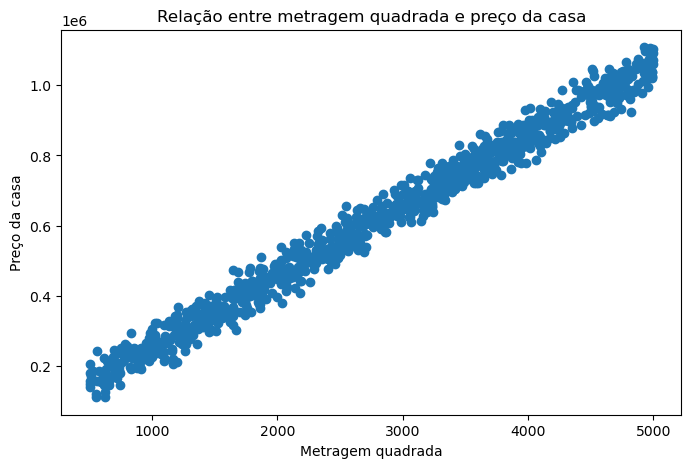

In [9]:
# TODO: crie um gráfico de dispersão entre metragem quadrada e preço da casa

# plt.figure(figsize=(8, 5))
# plt.scatter(df_modelo["Square_Footage"], df_modelo["House_Price"])
# plt.xlabel("Metragem quadrada")
# plt.ylabel("Preço da casa")
# plt.title("Relação entre metragem quadrada e preço da casa")
# plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df_modelo["Square_Footage"], df_modelo["House_Price"])
plt.xlabel("Metragem quadrada")
plt.ylabel("Preço da casa")
plt.title("Relação entre metragem quadrada e preço da casa")
plt.show()

### Pergunta

Pelo gráfico, casas com maior metragem quadrada tendem a ter preço maior? Explique com suas palavras.

## Parte 5 — Separação entre features e variável alvo

Crie:

- `X`: com as colunas de entrada do modelo.
- `y`: com a variável que queremos prever.

In [10]:
# TODO: crie X e y

features = ["Square_Footage", "Num_Bedrooms", "Neighborhood_Quality"]
alvo = "House_Price"

# X = ...
# y = ...

X = df[features]
Y = df[alvo]

print(X)
print(Y)

     Square_Footage  Num_Bedrooms  Neighborhood_Quality
0              1360             2                     5
1              4272             3                     6
2              3592             1                     9
3               966             1                     8
4              4926             2                     8
..              ...           ...                   ...
995            3261             4                    10
996            3179             1                    10
997            2606             4                     2
998            4723             5                     7
999            3268             4                     2

[1000 rows x 3 columns]
0      2.623829e+05
1      9.852609e+05
2      7.779774e+05
3      2.296989e+05
4      1.041741e+06
           ...     
995    7.014940e+05
996    6.837232e+05
997    5.720240e+05
998    9.648653e+05
999    7.425993e+05
Name: House_Price, Length: 1000, dtype: float64


## Parte 6 — Validação Holdout

Separe os dados em treino e teste usando:

- 80% para treino.
- 20% para teste.
- `random_state=42`.

In [11]:
# TODO: faça a separação holdout

# X_train, X_test, y_train, y_test = train_test_split(...)

# print("Treino:", X_train.shape)
# print("Teste:", X_test.shape)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Treino:", X_train.shape)
print("Teste", X_test.shape)

Treino: (800, 3)
Teste (200, 3)


## Parte 7 — Modelo: Regressão Linear

Crie, treine e avalie um modelo de Regressão Linear.

In [12]:
# TODO: crie e treine o modelo de regressão linear

# modelo_linear = ...
# modelo_linear.fit(X_train, y_train)

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
# TODO: faça previsões com o modelo linear

# pred_linear = ...

pred_linear = modelo_linear.predict(X_test)
print("Primeiras 5 previsões:", pred_linear[:5])

Primeiras 5 previsões: [ 859375.30392381  516934.77897239  979812.8054924  1032517.07677196
  766865.8341092 ]


In [14]:
# TODO: calcule MAE e MSE do modelo linear

# mae_linear = ...
# mse_linear = ...

# print("Regressão Linear")
# print("MAE:", mae_linear)
# print("MSE:", mse_linear)

mae_linear = mean_absolute_error(y_test, pred_linear)
mse_linear = mean_squared_error(y_test, pred_linear)

print("Regressão Linear")
print("MAE:", mae_linear)
print("MSE", mse_linear)

Regressão Linear
MAE: 24040.757156274252
MSE 873278475.6719671


## Parte 8 — Conclusão

Responda:

1. Qual foi o valor do MAE?
R: o valor do MAE foi 24.040,76

2. Qual foi o valor do MSE?
R: o valor do MSE foi 873.278.474

3. O que significa MAE?
R: MAE significa Mean Absolute Error que calcula a diferença absoluta

4. O que significa MSE?
R: MSE significa Mean Square Erro que calcula a média dos erros elevado ao quadrado

5. O modelo de Regressão Linear conseguiu prever bem o preço dos imóveis? Justifique com suas palavras.
R: Acho que conseguiu prever de acordo como esperado, pois comparando a média de preços com a MAE, o erro foi baixo.

## Critérios de avaliação

| Critério | Pontos |
|---|---:|
| Carregamento correto do dataset | 1,0 |
| Análise inicial dos dados | 1,5 |
| Seleção correta das features e variável alvo | 1,5 |
| Separação holdout correta | 1,0 |
| Criação e treinamento da Regressão Linear | 2,0 |
| Cálculo correto de MAE e MSE | 1,5 |
| Interpretação final dos resultados | 1,5 |
| **Total** | **10,0** |